In [2]:
import numpy as np
from scipy.spatial import distance
from sklearn.metrics.pairwise import cosine_similarity

# Euclidean Distance
def euclidean_distance(a, b):
    return np.linalg.norm(a - b)

# Manhattan Distance
def manhattan_distance(a, b):
    return np.abs(a - b).sum()

# Minkowski Distance
def minkowski_distance(a, b, p):
    return np.power(np.sum(np.abs(a - b) ** p), 1 / p)

# Hamming Distance
def hamming_distance(a, b):
    return (a != b).sum()

# Jaccard Similarity
def jaccard_similarity(a, b):
    intersection = len(set(a).intersection(set(b)))
    union = len(set(a).union(set(b)))
    return intersection / union

# Mahalanobis Distance
def mahalanobis_distance(a, b, VI):
    return distance.mahalanobis(a, b, VI)

# Correlation
def correlation(a, b):
    return np.corrcoef(a, b)[0, 1]

# Bhattacharyya Distance
def bhattacharyya_distance(a, b):
    return -np.log(np.sum(np.sqrt(a * b)))


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import os
# import random
import tensorflow as tf
from pathlib import Path
# from keras import applications
# from keras import layers
# from keras import losses
# from keras import ops
# from keras import optimizers
# from keras import metrics
# from keras import Model


target_shape = (227, 227)

In [5]:

anchor_images_path = Path("20K_Crack_Dataset/Anchor")
positive_images_path =Path("20K_Crack_Dataset/Positive")

In [7]:

def preprocess_image(filename):
    """
    Load the specified file as a JPEG image, preprocess it and
    resize it to the target shape.
    """

    image_string = tf.io.read_file(filename)
    image = tf.image.decode_jpeg(image_string, channels=3)
    image = tf.image.convert_image_dtype(image, tf.float32)
    image = tf.image.resize(image, target_shape)
    return image


def preprocess_triplets(anchor, positive, negative):
    """
    Given the filenames corresponding to the three images, load and
    preprocess them.
    """

    return (
        preprocess_image(anchor),
        preprocess_image(positive),
        preprocess_image(negative),
    )


In [17]:
# sorted order 
anchor_images = sorted(
    [str(anchor_images_path / f) for f in os.listdir(anchor_images_path)]
)[15000:]

positive_images = sorted(
    [str(positive_images_path / f) for f in os.listdir(positive_images_path)]
)[15000:]

image_count = len(anchor_images)

anchor_dataset = tf.data.Dataset.from_tensor_slices(anchor_images)
positive_dataset = tf.data.Dataset.from_tensor_slices(positive_images)


rng = np.random.RandomState(seed=42)
rng.shuffle(anchor_images)
rng.shuffle(positive_images)

negative_images = anchor_images + positive_images
np.random.RandomState(seed=32).shuffle(negative_images)

negative_dataset = tf.data.Dataset.from_tensor_slices(negative_images)
negative_dataset = negative_dataset.shuffle(buffer_size=4096)

dataset = tf.data.Dataset.zip((anchor_dataset, positive_dataset, negative_dataset))
dataset = dataset.shuffle(buffer_size=1024)
dataset = dataset.map(preprocess_triplets)


test_dataset = dataset.take(round(image_count))

print(len(test_dataset))

test_dataset = test_dataset.batch(32, drop_remainder=False)
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)



5000


In [18]:
def visualize(anchor, positive, negative):
    """Visualize a few triplets from the supplied batches."""

    def show(ax, image):
        ax.imshow(image)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    fig = plt.figure(figsize=(9, 9))

    axs = fig.subplots(1, 3)

    show(axs[0], anchor)
    show(axs[1], positive)
    show(axs[2], negative)

In [1]:
from keras.applications import resnet
import keras
import cv2

embedding = keras.saving.load_model("embedding6.keras")

In [19]:
from keras.applications import resnet
j=0
T=0
N=0
F=0
Positive_distance=[]
Negative_distance=[]

import keras
# sample = next(iter(test_dataset))
for sample in test_dataset:
  anchor, positive, negative = sample
  for i in range(len(anchor)):
    anchor_embedding, positive_embedding, negative_embedding = (
        embedding(resnet.preprocess_input(anchor[i][None,:,:,:])),
        embedding(resnet.preprocess_input(positive[i][None,:,:,:])),
        embedding(resnet.preprocess_input(negative[i][None,:,:,:])),
    )
    
    positive_similarity = manhattan_distance(anchor_embedding, positive_embedding)
    print(f"Positive distance {i}: ", positive_similarity)
    negative_similarity = manhattan_distance(anchor_embedding, negative_embedding)
    print(f"Negative distance {i}: ", negative_similarity)
    j+=1
    print(f'-------------------------------- {j} of {image_count} ---------------------------------------')
    Positive_distance.append(positive_similarity)
    Negative_distance.append(negative_similarity)
    if (negative_similarity - positive_similarity)> 2:
      T=T+1
    elif 4>(negative_similarity - positive_similarity)>0:
      N=N+1
    else:
      F=F+1

print('True=',T)
print('Nuture= ',N)
print('False= ',F)


Positive distance 0:  5.9885173
Negative distance 0:  24.85022
-------------------------------- 1 of 5000 ---------------------------------------
Positive distance 1:  4.8127823
Negative distance 1:  19.743162
-------------------------------- 2 of 5000 ---------------------------------------
Positive distance 2:  6.08099
Negative distance 2:  12.926878
-------------------------------- 3 of 5000 ---------------------------------------
Positive distance 3:  3.9746473
Negative distance 3:  26.860449
-------------------------------- 4 of 5000 ---------------------------------------
Positive distance 4:  1.6848989
Negative distance 4:  18.65982
-------------------------------- 5 of 5000 ---------------------------------------
Positive distance 5:  4.766831
Negative distance 5:  12.827798
-------------------------------- 6 of 5000 ---------------------------------------
Positive distance 6:  6.4117103
Negative distance 6:  11.831399
-------------------------------- 7 of 5000 ----------------

In [20]:
import pandas as pd

Dict={'Positive distance': Positive_distance ,'Negative distance': Negative_distance }
df = pd.DataFrame(Dict)
     
df.to_csv('distances.csv')

In [27]:
wrong=0
for i in range(len(Positive_distance)):
    delta= Negative_distance[i]-Positive_distance[i]
    # print(Negative_distance[i])    
    if delta < 4.5 :
        wrong+=1

# print(Positive_distance[i])       
print('false positives= ',wrong)
print((wrong*100)/5000)
        

false positives=  144
2.88


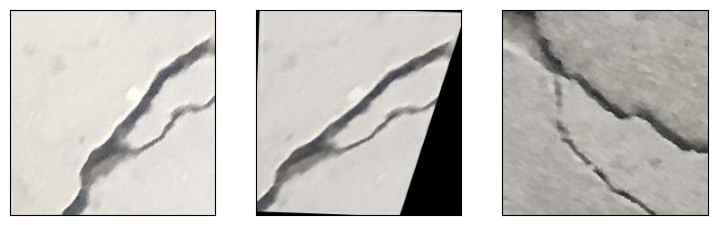

In [ ]:
visualize(anchor[1], positive[1], negative[1])